In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.plot import plot_graph

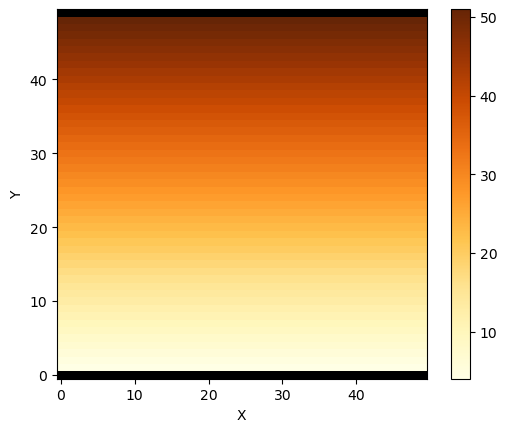

In [13]:
num_rows = 50  # number of grid rows
num_cols = 50  # number of grid columns
dxy = 1  # resolution of raster cell [m], or node horizontal and vertical spacing
grid = RasterModelGrid((num_rows, num_cols), dxy)
#This make sures that only the middle nodes/ rows are processed and leave the boundaries as is
grid.set_closed_boundaries_at_grid_edges(right_is_closed=False, 
                                         top_is_closed=True, 
                                         left_is_closed=False, 
                                         bottom_is_closed=True)

#create the initial simplified ramp topography
topo = grid.add_zeros('topographic__elevation', at='node')
cliff_height = 3
for i in range(num_rows):
    start = i * num_rows
    end = start + num_rows
    topo[start:end] = cliff_height
    cliff_height += 1
    
# Plot the topo map
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

In [14]:
#np.random.seed(0)  
#grid_noise = np.random.rand(grid.number_of_nodes) / 1000.0
#grid += grid_noise
sea_level = 6.0
erosion_rate = 0.5  # or set zr[i] = sea_level to cut/flatten directly
uplift_rate_m_yr = 2.1/1000 # 2.1 mm/yr avg uplift
dt = 1000 # timestep (yr)
uplift = uplift_rate_m_yr * dt
time_to_run = 1e6  # time for the model loop to run [yr]
nsteps = int(time_to_run / dt)  # number of model time steps

In [15]:
for step in range (nsteps):
    topo[grid.core_nodes]+= uplift
# Loop over every node on the grid (removed the + 1)
for i in range(grid.number_of_nodes):
    if topo[i] < sea_level:
        topo[i] -= erosion_rate  # Erode node if it is underwater
middle_nodes = grid.nodes[25, :] # nodes in the middle of the plot or half of 50

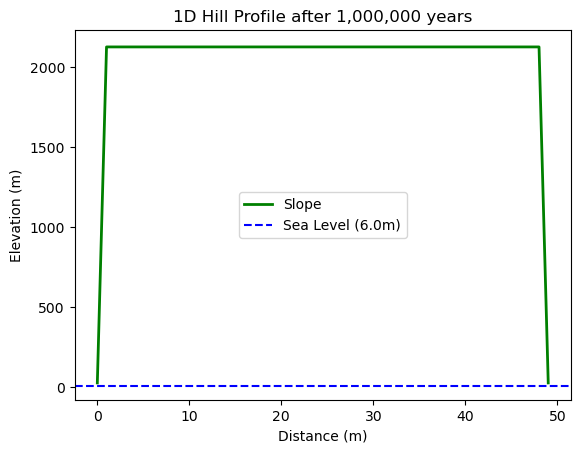

In [16]:
plt.plot(grid.node_x[middle_nodes], topo[middle_nodes], color='green', linewidth=2, label='Slope')
plt.axhline(sea_level, color='blue', linestyle='--', label='Sea Level (6.0m)')

plt.title(f'1D Hill Profile after {time_to_run:,.0f} years')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.legend()
plt.show()